  Algorithm  Avg Waiting Time  Avg Turnaround Time  Throughput
0      FCFS          5295.251             5305.680    0.095979
1       SJN          3585.613             3596.042    0.095979
2        RR          6862.917             6873.346    0.095979


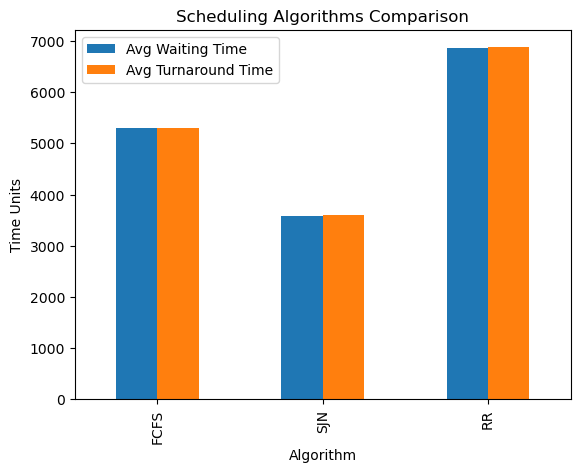

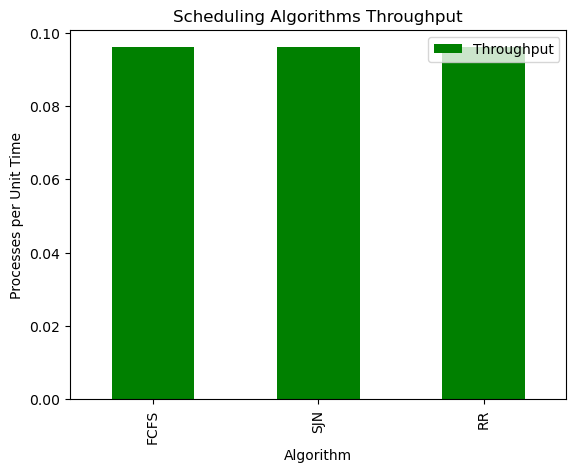

In [5]:
import random
import pandas as pd
import matplotlib.pyplot as plt

# Process class (using dictionary for simplicity as in the original code)
def generate_processes(num_processes):
    processes = []
    for pid in range(1, num_processes + 1):
        arrival_time = random.randint(0, 10)
        burst_time = random.randint(1, 20)
        processes.append({'pid': pid, 'arrival_time': arrival_time, 'burst_time': burst_time})
    return sorted(processes, key=lambda x: x['arrival_time'])

# FCFS Scheduling
def fcfs(processes):
    time = 0
    waiting_times = []
    turnaround_times = []

    for p in processes:
        if time < p['arrival_time']:
            time = p['arrival_time']
        waiting = time - p['arrival_time']
        turnaround = waiting + p['burst_time']
        waiting_times.append(waiting)
        turnaround_times.append(turnaround)
        time += p['burst_time']

    return waiting_times, turnaround_times

# SJN Scheduling
def sjn(processes):
    time = 0
    waiting_times = {}
    turnaround_times = {}
    ready_queue = []
    remaining = sorted(processes, key=lambda x: (x['arrival_time'], x['burst_time']))
    completed = []

    while remaining or ready_queue:
        # Add arriving processes to the ready queue
        while remaining and remaining[0]['arrival_time'] <= time:
            ready_queue.append(remaining.pop(0))

        if ready_queue:
            ready_queue.sort(key=lambda x: x['burst_time'])
            current = ready_queue.pop(0)
            waiting = time - current['arrival_time']
            waiting_times[current['pid']] = waiting
            turnaround_times[current['pid']] = waiting + current['burst_time']
            time += current['burst_time']
            completed.append(current['pid'])
        elif remaining:
            time = remaining[0]['arrival_time']
        else:
            break

    return list(waiting_times.values()), list(turnaround_times.values())

# Round Robin scheduling
def round_robin(processes, quantum):
    time = 0
    queue = []
    arrived = sorted(processes, key=lambda p: p['arrival_time'])
    remaining_time = {p['pid']: p['burst_time'] for p in processes}
    waiting_times = {p['pid']: 0 for p in processes}
    turnaround_times = {}
    process_arrival_time = {p['pid']: p['arrival_time'] for p in processes}

    while arrived or queue or any(remaining_time.values()):
        # Add arriving processes to the queue
        while arrived and arrived[0]['arrival_time'] <= time:
            queue.append(arrived.pop(0))

        if queue:
            current = queue.pop(0)
            pid = current['pid']
            start_time = time

            execution_time = min(quantum, remaining_time[pid])
            time += execution_time
            remaining_time[pid] -= execution_time

            waiting_times[pid] += start_time - process_arrival_time[pid]
            process_arrival_time[pid] = time # Update last execution time

            # Add newly arrived processes during this time slice
            while arrived and arrived[0]['arrival_time'] <= time:
                queue.append(arrived.pop(0))

            if remaining_time[pid] > 0:
                queue.append(current)
            else:
                turnaround_times[pid] = time - current['arrival_time']
        elif arrived:
            time = arrived[0]['arrival_time']
        elif any(remaining_time.values()):
            # Should not ideally happen if logic is correct, but as a failsafe
            time += 1
        else:
            break

    return list(waiting_times.values()), list(turnaround_times.values())


# Simulation Runner
def run_simulation():
    num_processes = 1000
    processes = generate_processes(num_processes)

    fcfs_wait, fcfs_turnaround = fcfs(processes)
    sjn_wait, sjn_turnaround = sjn(processes)
    rr_wait, rr_turnaround = round_robin(processes, quantum=5)

    data = {
        'Algorithm': ['FCFS', 'SJN', 'RR'],
        'Avg Waiting Time': [sum(fcfs_wait)/len(fcfs_wait), sum(sjn_wait)/len(sjn_wait), sum(rr_wait)/len(rr_wait)],
        'Avg Turnaround Time': [sum(fcfs_turnaround)/len(fcfs_turnaround), sum(sjn_turnaround)/len(sjn_turnaround), sum(rr_turnaround)/len(rr_turnaround)],
        'Throughput': [num_processes/(max(fcfs_turnaround) if fcfs_turnaround else 1),
                       num_processes/(max(sjn_turnaround) if sjn_turnaround else 1),
                       num_processes/(max(rr_turnaround) if rr_turnaround else 1)]
    }

    df = pd.DataFrame(data)
    print(df)

    df.plot(x='Algorithm', y=['Avg Waiting Time', 'Avg Turnaround Time'], kind='bar')
    plt.title('Scheduling Algorithms Comparison')
    plt.ylabel('Time Units')
    plt.show()

    df.plot(x='Algorithm', y='Throughput', kind='bar', color='green')
    plt.title('Scheduling Algorithms Throughput')
    plt.ylabel('Processes per Unit Time')
    plt.show()

if __name__ == "__main__":
    run_simulation()